# Stage 2 Benchmark: Librosa vs OpenL3 vs YAMNet vs CLAP

Этот notebook сравнивает 4 метода извлечения аудио-признаков на основе graded relevance по `tags`.
Код рассчитан на CSV-файлы в `local_music_parser/data/` и использует cosine search, PCA, UMAP, MRR@10 и nDCG@10.

In [1]:
from __future__ import annotations

import math
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 160)

NOTEBOOK_DIR_CANDIDATES = [
    Path.cwd() / 'data',
    Path.cwd() / 'local_music_parser' / 'data',
    Path(__file__).resolve().parent / 'data' if '__file__' in globals() else None,
]
BASE_DIR = next((p for p in NOTEBOOK_DIR_CANDIDATES if p is not None and p.exists()), None)
if BASE_DIR is None:
    raise FileNotFoundError('Cannot locate data directory. Run notebook from repo root or from local_music_parser/.')
METHODS = ['librosa', 'openl3', 'yamnet', 'clap']
DEFAULT_PCA = 30
DEFAULT_K = 10
RELEVANCE_THRESHOLD = 0.8
MAX_DIST = 100.0

def load_dataset(method_name: str) -> tuple[pd.DataFrame, np.ndarray, StandardScaler]:
    path = BASE_DIR / f'{method_name}_dataset.csv'
    df = pd.read_csv(path)
    if df.shape[1] < 4:
        raise ValueError(f'{path} does not contain metadata + embeddings')

    meta = df.iloc[:, :3].copy()
    meta.columns = ['msg_id', 'filename', 'tags']
    meta['msg_id'] = pd.to_numeric(meta['msg_id'], errors='coerce').astype('Int64')
    meta['tags'] = pd.to_numeric(meta['tags'].astype(str).str.strip(), errors='coerce').fillna(-1).astype(int)

    X = df.iloc[:, 3:].apply(pd.to_numeric, errors='coerce').fillna(0.0).to_numpy(dtype=np.float32)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return meta, X_scaled, scaler

def calculate_relevance(code_a: float, code_b: float, max_dist: float = MAX_DIST) -> float:
    return max(0.0, 1.0 - abs(float(code_a) - float(code_b)) / float(max_dist))

def pairwise_relevance_matrix(tags: np.ndarray, max_dist: float = MAX_DIST) -> np.ndarray:
    tags = np.asarray(tags, dtype=float).reshape(-1, 1)
    return np.clip(1.0 - np.abs(tags - tags.T) / float(max_dist), 0.0, 1.0)

def maybe_pca(X: np.ndarray, pca_components: int | None, random_state: int = 42) -> tuple[np.ndarray, PCA | None]:
    if pca_components is None:
        return X, None
    n_components = min(int(pca_components), X.shape[0] - 1, X.shape[1])
    if n_components < 2:
        return X, None
    pca = PCA(n_components=n_components, random_state=random_state)
    return pca.fit_transform(X), pca

def build_neighbors(X: np.ndarray, k_neighbors: int = DEFAULT_K, metric: str = 'cosine', pca_components: int | None = DEFAULT_PCA) -> tuple[list[list[int]], float, np.ndarray, PCA | None]:
    X_proc, pca = maybe_pca(X, pca_components)
    n_neighbors = min(k_neighbors + 1, len(X_proc))
    nn = NearestNeighbors(n_neighbors=n_neighbors, metric=metric, algorithm='brute')
    start = time.perf_counter()
    nn.fit(X_proc)
    _, indices = nn.kneighbors(X_proc)
    elapsed = time.perf_counter() - start
    neighbors = [[j for j in row if j != i][:k_neighbors] for i, row in enumerate(indices)]
    return neighbors, elapsed, X_proc, pca

def ndcg_at_k(relevances: list[float], ideal_relevances: list[float]) -> float:
    if not relevances:
        return 0.0
    discounts = np.log2(np.arange(2, len(relevances) + 2))
    dcg = float(np.sum(np.asarray(relevances) / discounts))
    if not ideal_relevances:
        return 0.0
    ideal_discounts = np.log2(np.arange(2, len(ideal_relevances) + 2))
    idcg = float(np.sum(np.asarray(ideal_relevances) / ideal_discounts))
    return dcg / idcg if idcg > 0 else 0.0

def evaluate_method(meta: pd.DataFrame, X: np.ndarray, pca_components: int | None = DEFAULT_PCA, k_neighbors: int = DEFAULT_K, metric: str = 'cosine') -> dict:
    tags = meta['tags'].to_numpy(dtype=float)
    rel_matrix = pairwise_relevance_matrix(tags)
    neighbors, elapsed, X_proc, pca = build_neighbors(X, k_neighbors=k_neighbors, metric=metric, pca_components=pca_components)

    rows = []
    mrrs, ndcgs, mean_rels = [], [], []
    for i in tqdm(range(len(meta)), desc='Scoring', leave=False):
        nbrs = neighbors[i]
        rels = rel_matrix[i, nbrs].tolist()
        mean_rel = float(np.mean(rels)) if rels else 0.0
        mean_rels.append(mean_rel)

        rr = 0.0
        for rank, rel in enumerate(rels, start=1):
            if rel > RELEVANCE_THRESHOLD:
                rr = 1.0 / rank
                break
        mrrs.append(rr)

        ideal = np.sort(np.delete(rel_matrix[i], i))[::-1][:k_neighbors].tolist()
        ndcg = ndcg_at_k(rels, ideal)
        ndcgs.append(ndcg)

        rows.append({
            'query_idx': i,
            'filename': meta.iloc[i]['filename'],
            'code_query': int(tags[i]),
            'neighbor_indices': nbrs,
            'neighbor_codes': [int(tags[j]) for j in nbrs],
            'neighbor_relevances': rels,
            'mean_relevance_topk': mean_rel,
            'mrr_contrib': rr,
            'ndcg_contrib': ndcg,
        })

    return {
        'pca_components': pca_components,
        'k_neighbors': k_neighbors,
        'metric': metric,
        'inference_time_sec': elapsed,
        'MRR@10': float(np.mean(mrrs)),
        'nDCG@10': float(np.mean(ndcgs)),
        'Mean Relevance': float(np.mean(mean_rels)),
        'X_processed': X_proc,
        'pca': pca,
        'neighbors': neighbors,
        'query_rows': rows,
        'relevance_matrix': rel_matrix,
    }


c:\Users\gasre\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
datasets = {}
for method in METHODS:
    meta, X, scaler = load_dataset(method)
    datasets[method] = {'meta': meta, 'X': X, 'scaler': scaler}

dataset_shapes = pd.DataFrame({
    'Method': list(datasets.keys()),
    'Rows': [len(v['meta']) for v in datasets.values()],
    'Embedding Dim': [v['X'].shape[1] for v in datasets.values()],
    'Tag Range': [f"{int(v['meta']['tags'].min())}..{int(v['meta']['tags'].max())}" for v in datasets.values()],
})
display(dataset_shapes)


,Method,Rows,Embedding Dim,Tag Range
0,librosa,132,512,2..95
1,openl3,132,512,2..95
2,yamnet,132,1024,2..95
3,clap,132,512,2..95



[TensorFlow DLL Diagnostic] Analyzing: c:\Users\gasre\AppData\Local\Programs\Python\Python311\Lib\site-packages\tensorflow\python\_pywrap_tensorflow_internal.pyd
[Error] Failed to load _pywrap_tensorflow_common.dll: INITIALIZATION FAILED (0x45A) - The DLL's DllMain returned false.
    Hint: This often happens if your CPU lacks required instructions (like AVX/AVX2)
    or if the Microsoft Visual C++ Redistributable is outdated/missing.


C:\Users\gasre\AppData\Local\Temp\ipykernel_26196\3475310930.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('hsv')
c:\Users\gasre\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\gasre\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\gasre\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\gasre\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap

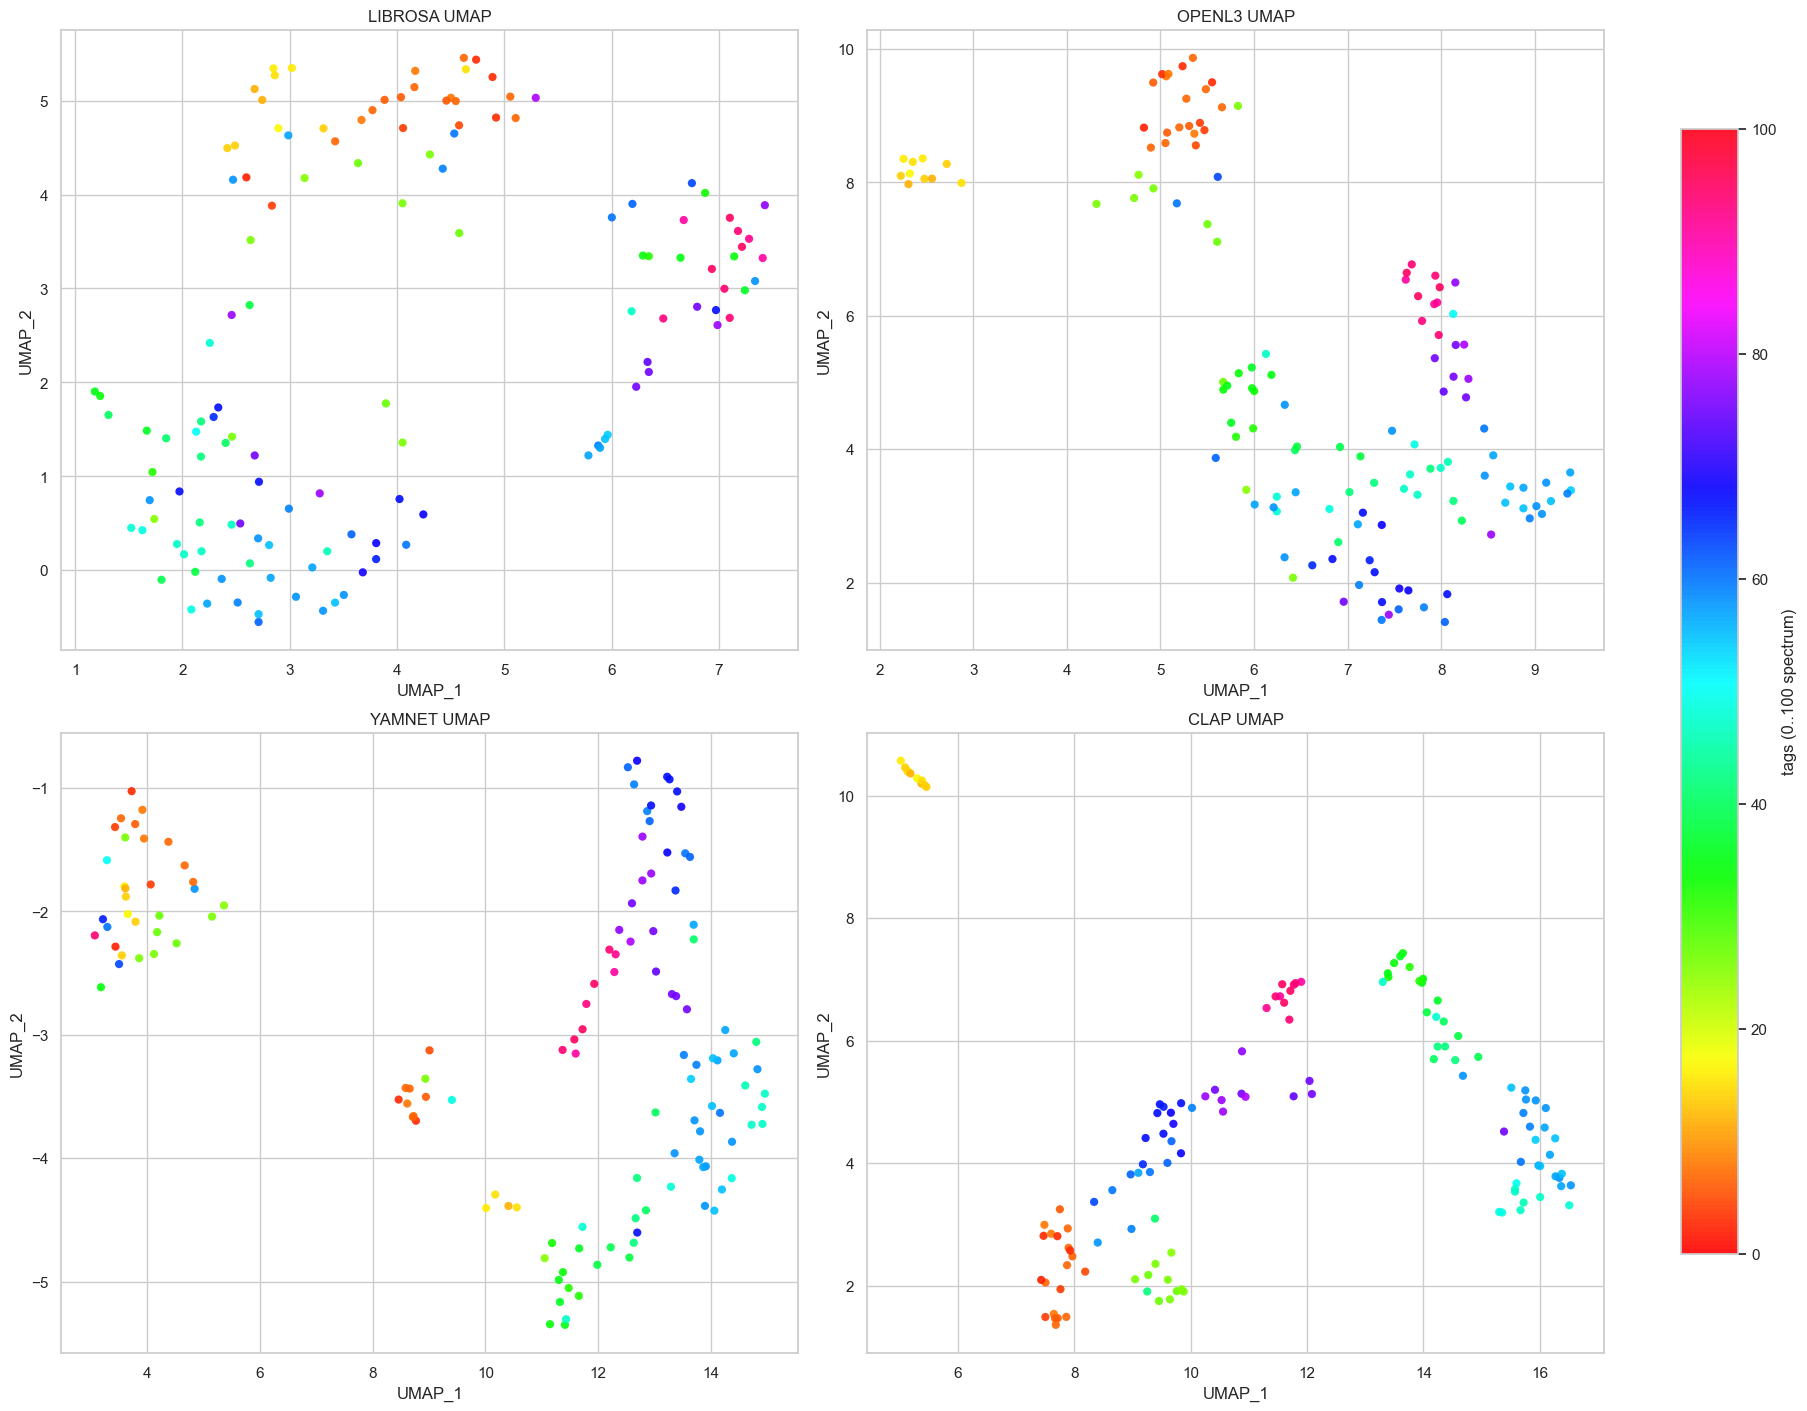

In [4]:
def plot_umap_grid(datasets: dict[str, dict], pca_components: int | None = DEFAULT_PCA) -> None:
    try:
        import umap
    except ImportError as exc:
        raise ImportError('Please install umap-learn to render UMAP plots.') from exc

    fig, axes = plt.subplots(2, 2, figsize=(18, 14), constrained_layout=True)
    cmap = plt.cm.get_cmap('hsv')
    norm = plt.Normalize(vmin=0, vmax=100)

    for ax, method in zip(axes.flat, METHODS):
        meta = datasets[method]['meta']
        X = datasets[method]['X']
        X_vis, _ = maybe_pca(X, pca_components)
        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
        emb2d = reducer.fit_transform(X_vis)
        sc = ax.scatter(
            emb2d[:, 0],
            emb2d[:, 1],
            c=meta['tags'],
            cmap=cmap,
            norm=norm,
            s=35,
            alpha=0.9,
            edgecolors='none',
        )
        ax.set_title(f'{method.upper()} UMAP')
        ax.set_xlabel('UMAP_1')
        ax.set_ylabel('UMAP_2')

    cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), shrink=0.85)
    cbar.set_label('tags (0..100 spectrum)')
    plt.show()

plot_umap_grid(datasets, pca_components=DEFAULT_PCA)


In [5]:
baseline_rows = []
baseline_results = {}

for method in METHODS:
    payload = datasets[method]
    pca_components = DEFAULT_PCA if payload['X'].shape[1] > DEFAULT_PCA else None
    result = evaluate_method(payload['meta'], payload['X'], pca_components=pca_components, k_neighbors=DEFAULT_K, metric='cosine')
    baseline_results[method] = result
    baseline_rows.append({
        'Method': method,
        'PCA_components': pca_components if pca_components is not None else 'None',
        'K_neighbors': DEFAULT_K,
        'MRR@10': result['MRR@10'],
        'nDCG@10': result['nDCG@10'],
        'Mean Relevance': result['Mean Relevance'],
        'Inference Time (s)': result['inference_time_sec'],
    })

baseline_df = pd.DataFrame(baseline_rows).sort_values('nDCG@10', ascending=False).reset_index(drop=True)
display(baseline_df)


,Method,PCA_components,K_neighbors,MRR@10,nDCG@10,Mean Relevance,Inference Time (s)
0,clap,30,10,1.000000,0.946272,0.923508,0.002769
1,openl3,30,10,0.957281,0.925597,0.905136,0.003632
2,yamnet,30,10,0.932480,0.904599,0.882697,0.003585
3,librosa,30,10,0.871296,0.869987,0.852402,0.007695


PCA sweep: clap: 100%|██████████| 6/6 [00:00<00:00, 15.23it/s]


,Method,PCA_components,MRR@10,nDCG@10,Mean Relevance
18,clap,10,0.992424,0.955226,0.934311
19,clap,20,0.996212,0.945970,0.923409
20,clap,30,1.000000,0.946272,0.923508
21,clap,50,0.996212,0.944671,0.921848
22,clap,80,1.000000,0.944583,0.921197
23,clap,None,1.000000,0.945023,0.921795
0,librosa,10,0.874390,0.866931,0.847470
1,librosa,20,0.866065,0.867203,0.848477
2,librosa,30,0.871296,0.869987,0.852402
3,librosa,50,0.878641,0.870298,0.851765


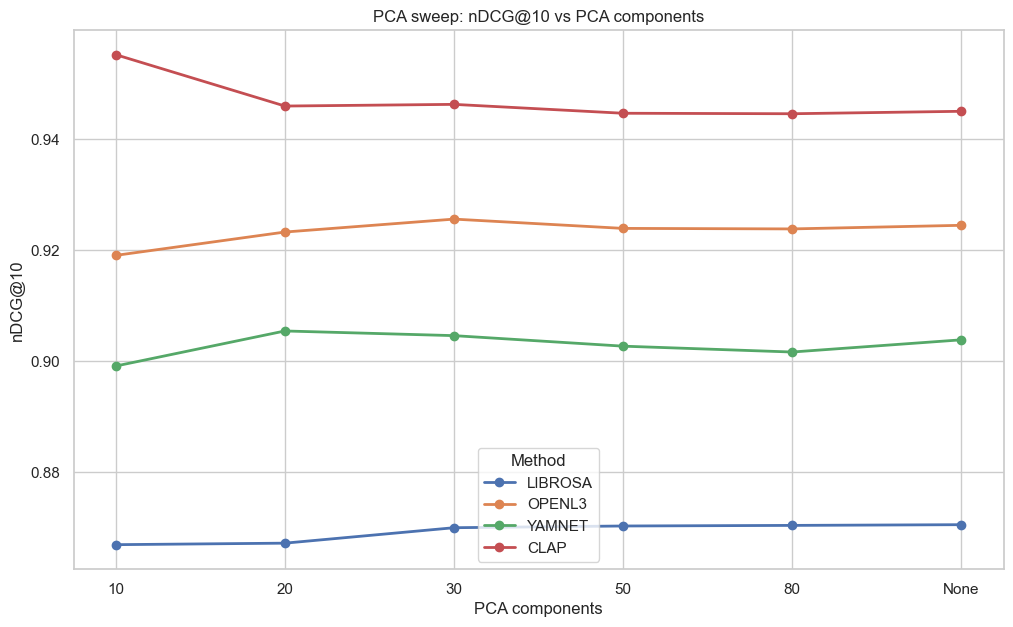

{'librosa': None, 'openl3': 30, 'yamnet': 20, 'clap': 10}

In [6]:
pca_values = [10, 20, 30, 50, 80, None]
pca_rows = []
best_pca_by_method = {}

for method in METHODS:
    payload = datasets[method]
    for pca_components in tqdm(pca_values, desc=f'PCA sweep: {method}'):
        result = evaluate_method(payload['meta'], payload['X'], pca_components=pca_components, k_neighbors=DEFAULT_K, metric='cosine')
        pca_rows.append({
            'Method': method,
            'PCA_components': 'None' if pca_components is None else int(pca_components),
            'MRR@10': result['MRR@10'],
            'nDCG@10': result['nDCG@10'],
            'Mean Relevance': result['Mean Relevance'],
        })

pca_df = pd.DataFrame(pca_rows)
display(pca_df.sort_values(['Method', 'PCA_components']))

plot_labels = [str(v) if v is not None else 'None' for v in pca_values]
x_positions = np.arange(len(pca_values))
fig, ax = plt.subplots(figsize=(12, 7))
for method in METHODS:
    sub = pca_df[pca_df['Method'] == method].copy()
    sub['PCA_label'] = sub['PCA_components'].astype(str)
    sub = sub.set_index('PCA_label').reindex(plot_labels)
    ax.plot(x_positions, sub['nDCG@10'].to_numpy(), marker='o', linewidth=2, label=method.upper())
    best_idx = int(np.nanargmax(sub['nDCG@10'].to_numpy()))
    best_pca_by_method[method] = pca_values[best_idx]

ax.set_xticks(x_positions)
ax.set_xticklabels(plot_labels)
ax.set_xlabel('PCA components')
ax.set_ylabel('nDCG@10')
ax.set_title('PCA sweep: nDCG@10 vs PCA components')
ax.legend(title='Method')
plt.show()

best_pca_by_method


K sweep: clap: 100%|██████████| 5/5 [00:00<00:00, 18.68it/s]


,Method,Best PCA,K,MRR@K,nDCG@K
15,clap,10,3,0.992424,0.968609
16,clap,10,5,0.992424,0.966793
17,clap,10,10,0.992424,0.955226
18,clap,10,15,0.992424,0.944287
19,clap,10,20,0.992424,0.935402
0,librosa,None,3,0.872475,0.881893
1,librosa,None,5,0.872475,0.875403
2,librosa,None,10,0.879209,0.870533
3,librosa,None,15,0.881013,0.866526
4,librosa,None,20,0.881013,0.863821


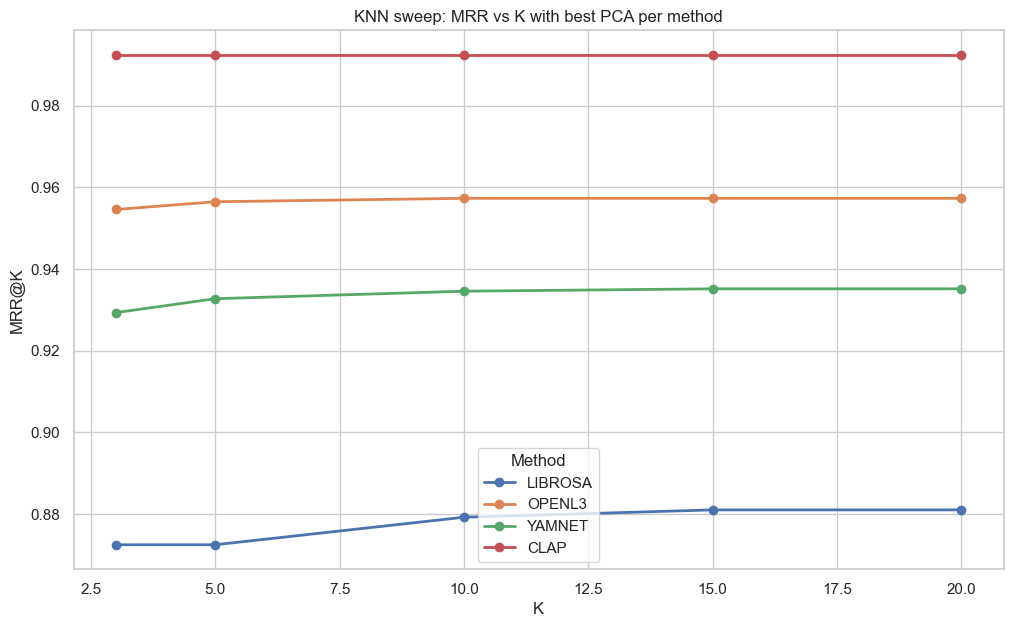

In [7]:
k_values = [3, 5, 10, 15, 20]
knn_rows = []

for method in METHODS:
    payload = datasets[method]
    best_pca = best_pca_by_method.get(method, DEFAULT_PCA)
    for k_neighbors in tqdm(k_values, desc=f'K sweep: {method}'):
        result = evaluate_method(payload['meta'], payload['X'], pca_components=best_pca, k_neighbors=k_neighbors, metric='cosine')
        knn_rows.append({
            'Method': method,
            'Best PCA': 'None' if best_pca is None else int(best_pca),
            'K': k_neighbors,
            'MRR@K': result['MRR@10'],
            'nDCG@K': result['nDCG@10'],
        })

knn_df = pd.DataFrame(knn_rows)
display(knn_df.sort_values(['Method', 'K']))

fig, ax = plt.subplots(figsize=(12, 7))
for method in METHODS:
    sub = knn_df[knn_df['Method'] == method].sort_values('K')
    ax.plot(sub['K'], sub['MRR@K'], marker='o', linewidth=2, label=method.upper())

ax.set_xlabel('K')
ax.set_ylabel('MRR@K')
ax.set_title('KNN sweep: MRR vs K with best PCA per method')
ax.legend(title='Method')
plt.show()


In [8]:
hallucination_rows = []

for method in METHODS:
    result = baseline_results[method]
    worst = min(result['query_rows'], key=lambda row: row['mean_relevance_topk'])
    hallucination_rows.append({
        'Method': method,
        'Filename': worst['filename'],
        'Code_Query': worst['code_query'],
        'Top10_Neighbor_Codes': worst['neighbor_codes'],
        'Top10_Relevance_Scores': worst['neighbor_relevances'],
        'Mean_Relevance_Top10': worst['mean_relevance_topk'],
    })

hallucination_df = pd.DataFrame(hallucination_rows)
display(hallucination_df)


,Method,Filename,Code_Query,Top10_Neighbor_Codes,Top10_Relevance_Scores,Mean_Relevance_Top10
0,librosa,Aphex Twin-Heliosphan.mp3,60,"[26, 6, 3, 15, 8, 5, 7, 7, 16, 7]","[0.6599999999999999, 0.45999999999999996, 0.43000000000000005, 0.55, 0.48, 0.44999999999999996, 0.47, 0.47, 0.56, 0.47]",0.500
1,openl3,Xtal - Aphex Twin.mp3,63,"[60, 6, 4, 93, 26, 77, 91, 8, 6, 94]","[0.97, 0.43000000000000005, 0.41000000000000003, 0.7, 0.63, 0.86, 0.72, 0.44999999999999996, 0.43000000000000005, 0.69]",0.629
2,yamnet,Nargaroth-Hate Song.mp3,94,"[14, 66, 50, 14, 2, 60, 63, 26, 26, 7]","[0.19999999999999996, 0.72, 0.56, 0.19999999999999996, 0.07999999999999996, 0.6599999999999999, 0.69, 0.31999999999999995, 0.31999999999999995, 0.13]",0.388
3,clap,Aphex Twin - Flim.mp3,58,"[59, 7, 5, 7, 4, 3, 7, 7, 3, 8]","[0.99, 0.49, 0.47, 0.49, 0.45999999999999996, 0.44999999999999996, 0.49, 0.49, 0.44999999999999996, 0.5]",0.528
